In [2]:
import pandas as pd
import numpy as np
df=pd.read_csv('fifa_eda.csv')
df.sample(5)

,ID,Name,Age,Nationality,Overall,Potential,Club,Value,Wage,Preferred Foot,International Reputation,Skill Moves,Position,Joined,Contract Valid Until,Height,Weight,Release Clause
9862,164339,M. Papadopulos,33,Czech Republic,66,66,Piast Gliwice,400.0,3.0,Right,1.0,2.0,ST,2017,2019-01-01,6.000000,174.0,540.000000
10950,237563,A. Badji,20,Senegal,65,76,Djurgårdens IF,950.0,2.0,Right,1.0,3.0,ST,2017,2020-01-01,6.166667,165.0,1400.000000
9749,204763,P. Steinhart,25,Germany,66,69,TSV 1860 München,675.0,2.0,Left,1.0,2.0,LM,2017,2021-01-01,6.000000,154.0,1000.000000
13960,242178,J. Ramírez,21,Colombia,61,70,Atlético Nacional,300.0,1.0,Right,1.0,1.0,GK,2018,2021-01-01,5.916667,165.0,480.000000
434,219809,T. Bakayoko,23,France,80,85,Milan,17000.0,85.0,Right,2.0,3.0,LCM,2016,2019-06-30,6.166667,187.0,4585.060806


In [6]:
import plotly.express as px
import numpy

In [35]:
#Elemento 1: Obtener matriz de correlación y dejarla como heat map
df_numeric = df.select_dtypes(include=['int64', 'float64'])
df_numeric.corr()

,ID,Age,Overall,Potential,Value,Wage,International Reputation,Skill Moves,Joined,Height,Weight,Release Clause
ID,1.000000,-0.739208,-0.417025,0.047074,-0.139837,-0.204610,-0.356191,-0.056914,0.206749,-0.090090,-0.191193,-0.121297
Age,-0.739208,1.000000,0.452350,-0.253312,0.078315,0.141145,0.253765,0.027649,-0.202658,0.082506,0.229940,0.058672
Overall,-0.417025,0.452350,1.000000,0.660939,0.631848,0.571926,0.499491,0.414463,-0.169281,0.038527,0.154557,0.597821
Potential,0.047074,-0.253312,0.660939,1.000000,0.579608,0.486413,0.372993,0.354290,-0.047661,-0.009791,-0.006935,0.562346
Value,-0.139837,0.078315,0.631848,0.579608,1.000000,0.858086,0.656158,0.317246,-0.115991,0.002827,0.046702,0.973310
Wage,-0.204610,0.141145,0.571926,0.486413,0.858086,1.000000,0.668635,0.263205,-0.142337,0.019638,0.064764,0.828161
International Reputation,-0.356191,0.253765,0.499491,0.372993,0.656158,0.668635,1.000000,0.208153,-0.133009,0.034881,0.088340,0.620863
Skill Moves,-0.056914,0.027649,0.414463,0.354290,0.317246,0.263205,0.208153,1.000000,0.020692,-0.422753,-0.351209,0.297471
Joined,0.206749,-0.202658,-0.169281,-0.047661,-0.115991,-0.142337,-0.133009,0.020692,1.000000,0.001188,-0.028274,-0.115374
Height,-0.090090,0.082506,0.038527,-0.009791,0.002827,0.019638,0.034881,-0.422753,0.001188,1.000000,0.754678,0.001835


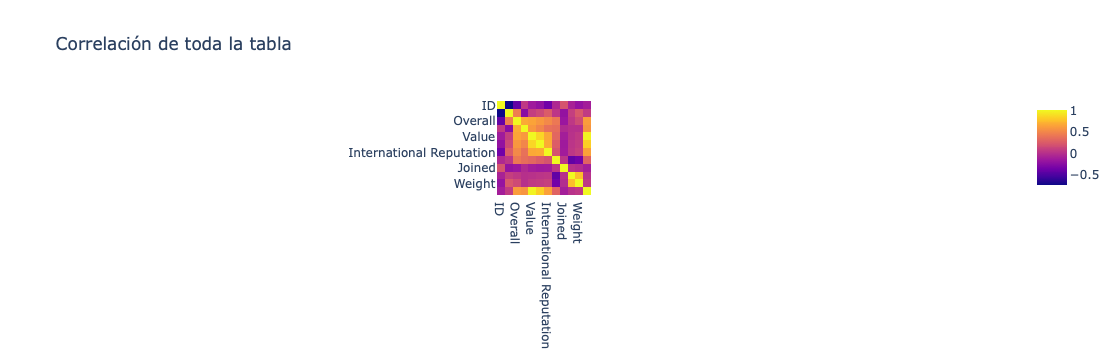

In [37]:
fig=px.imshow(df_numeric.corr(), text_auto=True,title='Correlación de toda la tabla')
fig.show()

In [27]:
#Elemento 2: Gráfico de Correlación que responda ¿Cuál es la relación entre la edad y el overall?. EXplica la salida
df_edad=df.groupby(['Overall','Age']).size().rename('Cantidad').reset_index()
df_edad

,Overall,Age,Cantidad
0,46,16,1
1,47,16,1
2,47,17,2
3,47,18,12
4,47,19,4
...,...,...,...
780,91,31,1
781,91,32,2
782,92,26,1
783,94,31,1


In [28]:
df_edad.corr()

,Overall,Age,Cantidad
Overall,1.000000,0.196279,-0.148362
Age,0.196279,1.000000,-0.289819
Cantidad,-0.148362,-0.289819,1.000000


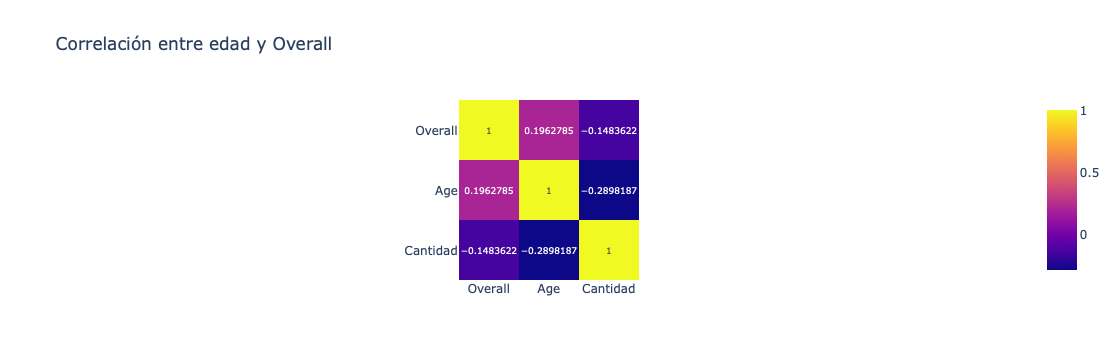

In [29]:
fig=px.imshow(df_edad.corr(), text_auto=True,title='Correlación entre edad y Overall')
fig.show()


Explicación: podemos observar que existe una relación de la edad y overall de 0.1962 (una relación baja)

In [40]:
#Elemento 3: Generar un grafico de barras por club que indique el número de jugadores
df_club=df.groupby(['Club']).size().rename('Cantidad').reset_index()
df_club

,Club,Cantidad
0,SSV Jahn Regensburg,29
1,1. FC Heidenheim 1846,28
2,1. FC Kaiserslautern,26
3,1. FC Köln,28
4,1. FC Magdeburg,26
...,...,...
646,Zagłębie Sosnowiec,25
647,Çaykur Rizespor,30
648,Örebro SK,27
649,Östersunds FK,22


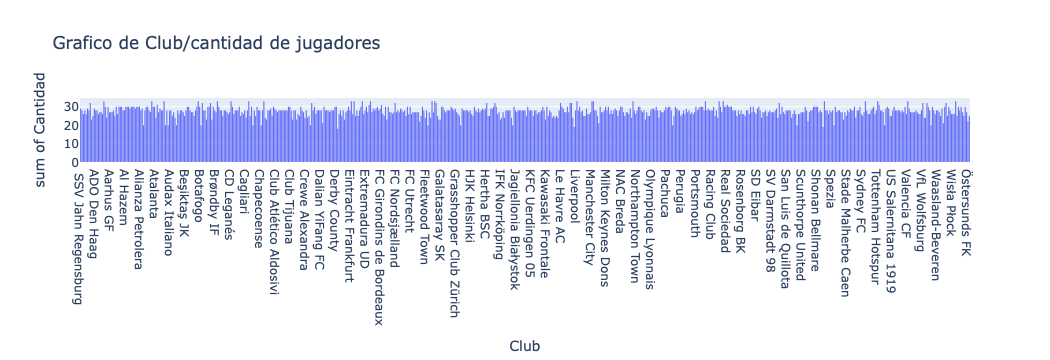

In [47]:
fig=px.histogram(df_club, x='Club',y='Cantidad', title='Grafico de Club/cantidad de jugadores')
fig.show()

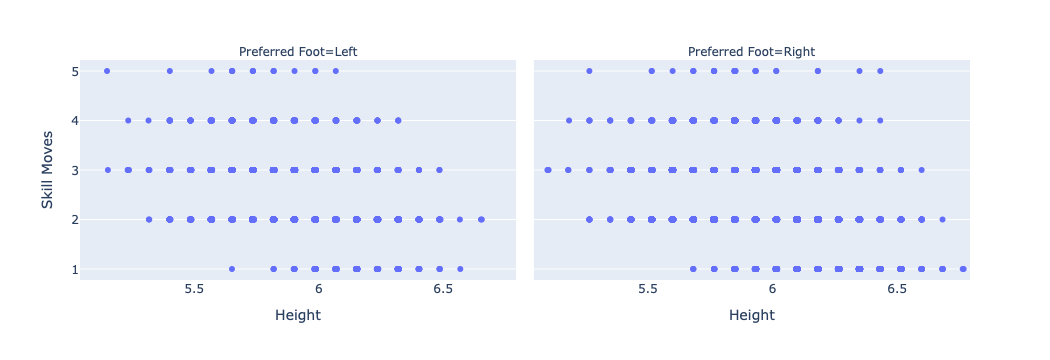

In [55]:
#Elemento 4: Hacer un gráfico multipanel que indique la realcion altura (height) vs skill moves, siendo la variable del panel si es zurdo o derecho
fig = px.strip(df, x='Height', y='Skill Moves', facet_col='Preferred Foot')
fig.show()

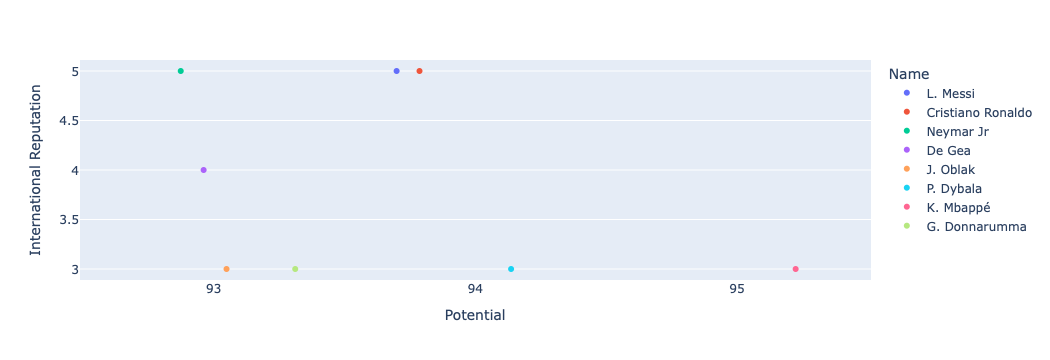

In [67]:
#Elemento 5: Un gráfico que crea importante para mostrar a los potenciales cracks

high_potential = df['Potential'] > 92
high_potential_df = df[high_potential]
fig = px.strip(high_potential_df, x='Potential', y='International Reputation', color='Name')

fig.show()